In [1]:
import numpy as np                     # For numerical operations
import pandas as pd                    # For data manipulation
import seaborn as sns                  # For loading sample datasets and plotting
import matplotlib.pyplot as plt        # For visualization
from sklearn.model_selection import train_test_split   # For splitting data into train/test sets
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures  # For scaling and feature engineering

In [2]:
%matplotlib inline


In [3]:
# We use the 'diamonds' dataset which includes numeric and categorical variables.
df = sns.load_dataset('diamonds')
print("Initial dataset shape:", df.shape)
df.head()  # Display the first few rows of the dataset

Initial dataset shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
# =============================================================================
# 2. Introduce and Fix Data Quality Issues
# =============================================================================

# ----- 2.1 Introduce Missing Values (Simulate Real-World 'Dirty' Data) -----
# Randomly set 1% of the entries in the 'price' column to missing.
np.random.seed(42)  # For reproducibility
missing_indices = np.random.choice(df.index, size=int(0.01*len(df)), replace=False)
df.loc[missing_indices, 'price'] = np.nan
print("\nMissing values introduced in 'price' column.")


Missing values introduced in 'price' column.


In [8]:
# ----- 2.2 Introduce Duplicate Rows -----
# Duplicate 5 random rows and append them to the dataframe.
duplicate_rows = df.sample(n=5, random_state=42)
df = pd.concat([df, duplicate_rows], ignore_index=True)
print("Duplicate rows added. New shape:", df.shape)

Duplicate rows added. New shape: (53945, 10)


In [9]:
# ----- 2.3 Simulate Structural Errors in Categorical Data -----
# For example, randomly change the case of some 'cut' entries (e.g., 'Premium' -> 'preMIum').
def introduce_structural_error(val):
    if np.random.rand() < 0.1:  # 10% chance to mess up the string format
        return val.lower()
    else:
        return val

df['cut'] = df['cut'].apply(introduce_structural_error)
print("Structural errors introduced in 'cut' column (case inconsistencies).")

Structural errors introduced in 'cut' column (case inconsistencies).


In [11]:
# ----- 2.4 Check Data Types and Validate/Convert if Necessary -----
# Display the data types to ensure they are as expected.
print("\nData Types before conversion:\n", df.dtypes)
# (For this dataset, the types are fine, but if needed, you could convert columns explicitly.)


Data Types before conversion:
 carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price       float64
x           float64
y           float64
z           float64
dtype: object


In [12]:
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows before removal:", duplicates)


Number of duplicate rows before removal: 149


In [15]:
# Remove duplicates.
df = df.drop_duplicates()
print("Duplicates removed. New dataset shape:", df.shape)

Duplicates removed. New dataset shape: (53796, 10)


In [17]:
# ----- 2.6 Handle Missing Values -----
# Examine missing values in each column.
print("\nMissing values in each column:\n", df.isnull().sum())


Missing values in each column:
 carat        0
cut          0
color        0
clarity      0
depth        0
table        0
price      539
x            0
y            0
z            0
dtype: int64


In [18]:
# For this example, we will impute missing 'price' values with the median.
median_price = df['price'].median()
df['price'].fillna(median_price, inplace=True)
print("Missing values in 'price' column imputed with median:", median_price)

Missing values in 'price' column imputed with median: 2401.0


In [19]:
# ----- 2.7 Handle Outliers -----
# Outliers can distort analysis. Here, we use the IQR method on the 'price' column.
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
# Define lower and upper bounds for outlier detection.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("\nPrice Outlier Lower Bound:", lower_bound, "Upper Bound:", upper_bound)



Price Outlier Lower Bound: -5536.0 Upper Bound: 11776.0


In [20]:
# Cap the outliers (here we cap extreme values)
df['price'] = np.where(df['price'] < lower_bound, lower_bound, df['price'])
df['price'] = np.where(df['price'] > upper_bound, upper_bound, df['price'])
print("Outliers in 'price' column capped at the lower and upper bounds.")

Outliers in 'price' column capped at the lower and upper bounds.


In [21]:
# =============================================================================
# 3. Exploratory Data Analysis (EDA)
# =============================================================================

F:\anacod\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


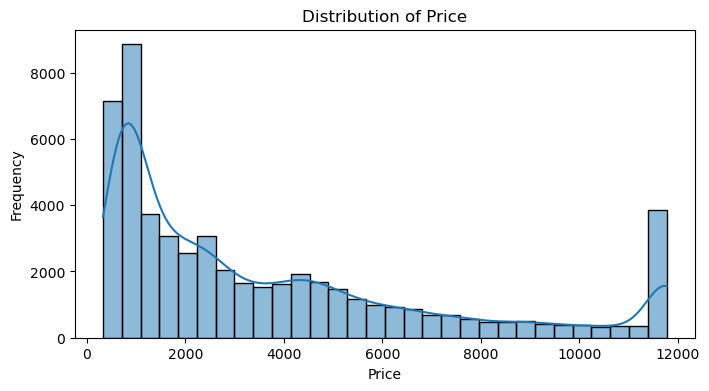

In [22]:
# ----- 3.1 Univariate Analysis -----
# Plot the distribution of a numerical variable: 'price'
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

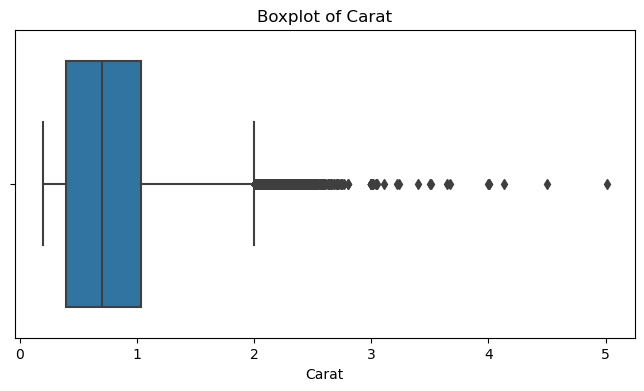

In [23]:
# Boxplot to visualize outliers in 'carat'
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['carat'])
plt.title('Boxplot of Carat')
plt.xlabel('Carat')
plt.show()


F:\anacod\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


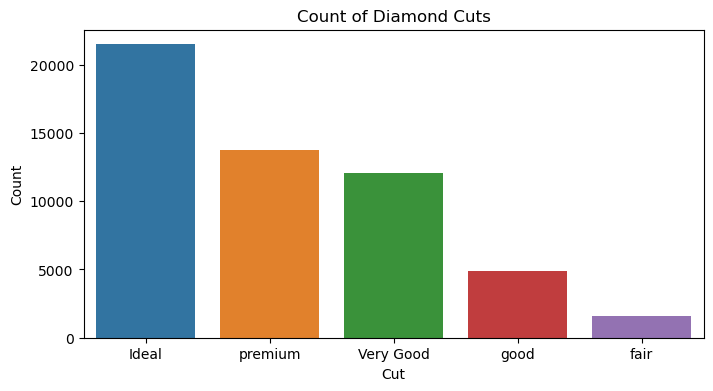

In [24]:
# Countplot for a categorical variable: 'cut'
plt.figure(figsize=(8, 4))
sns.countplot(x=df['cut'])
plt.title('Count of Diamond Cuts')
plt.xlabel('Cut')
plt.ylabel('Count')
plt.show()

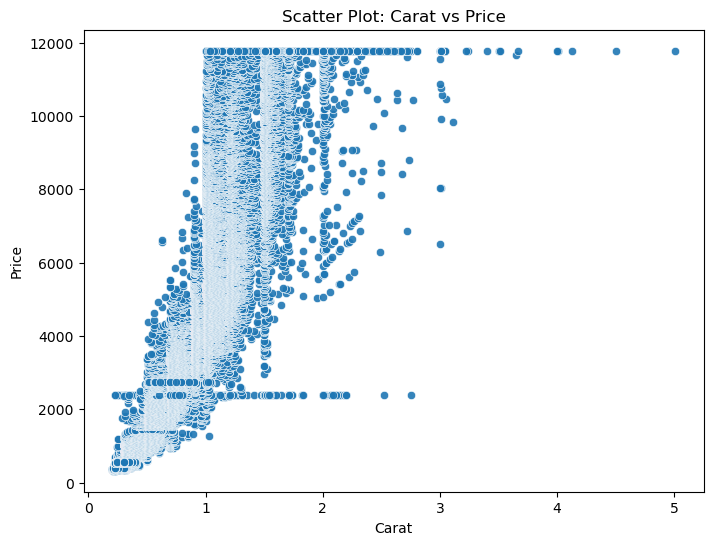

In [26]:
# ----- 3.2 Bivariate Analysis -----
# Scatter plot to see the relationship between 'carat' and 'price'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='carat', y='price', data=df, alpha=0.9)
plt.title('Scatter Plot: Carat vs Price')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()

F:\anacod\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


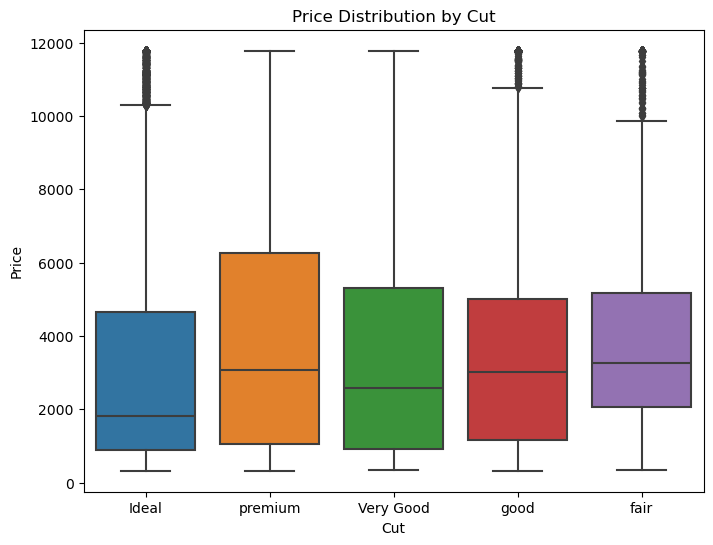

In [27]:
# Boxplot of price grouped by cut quality to see differences.
plt.figure(figsize=(8, 6))
sns.boxplot(x='cut', y='price', data=df)
plt.title('Price Distribution by Cut')
plt.xlabel('Cut')
plt.ylabel('Price')
plt.show()

In [28]:
# ----- 3.3 Multivariate Analysis and Correlation -----
# Compute correlation matrix for numerical variables.
corr_matrix = df.select_dtypes(include=[np.number]).corr()
print("\nCorrelation Matrix:\n", corr_matrix)


Correlation Matrix:
           carat     depth     table     price         x         y         z
carat  1.000000  0.027818  0.181115  0.922627  0.975380  0.951911  0.953543
depth  0.027818  1.000000 -0.297648 -0.006857 -0.025387 -0.029426  0.094717
table  0.181115 -0.297648  1.000000  0.132551  0.194863  0.183240  0.150284
price  0.922627 -0.006857  0.132551  1.000000  0.905197  0.885754  0.882490
x      0.975380 -0.025387  0.194863  0.905197  1.000000  0.974594  0.970688
y      0.951911 -0.029426  0.183240  0.885754  0.974594  1.000000  0.951848
z      0.953543  0.094717  0.150284  0.882490  0.970688  0.951848  1.000000


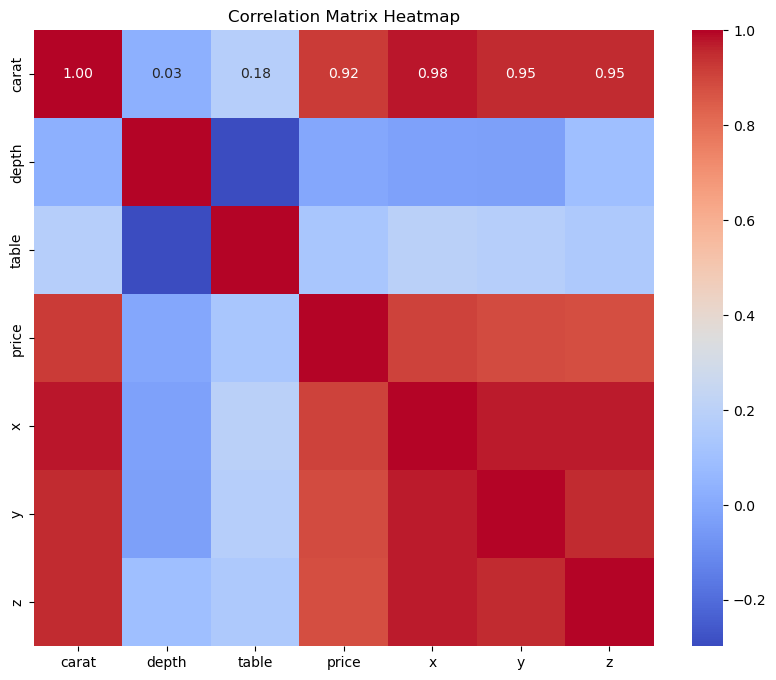

In [29]:
# Visualize the correlation matrix using a heatmap.
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

F:\anacod\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
F:\anacod\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
F:\anacod\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
F:\anacod\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', Tru

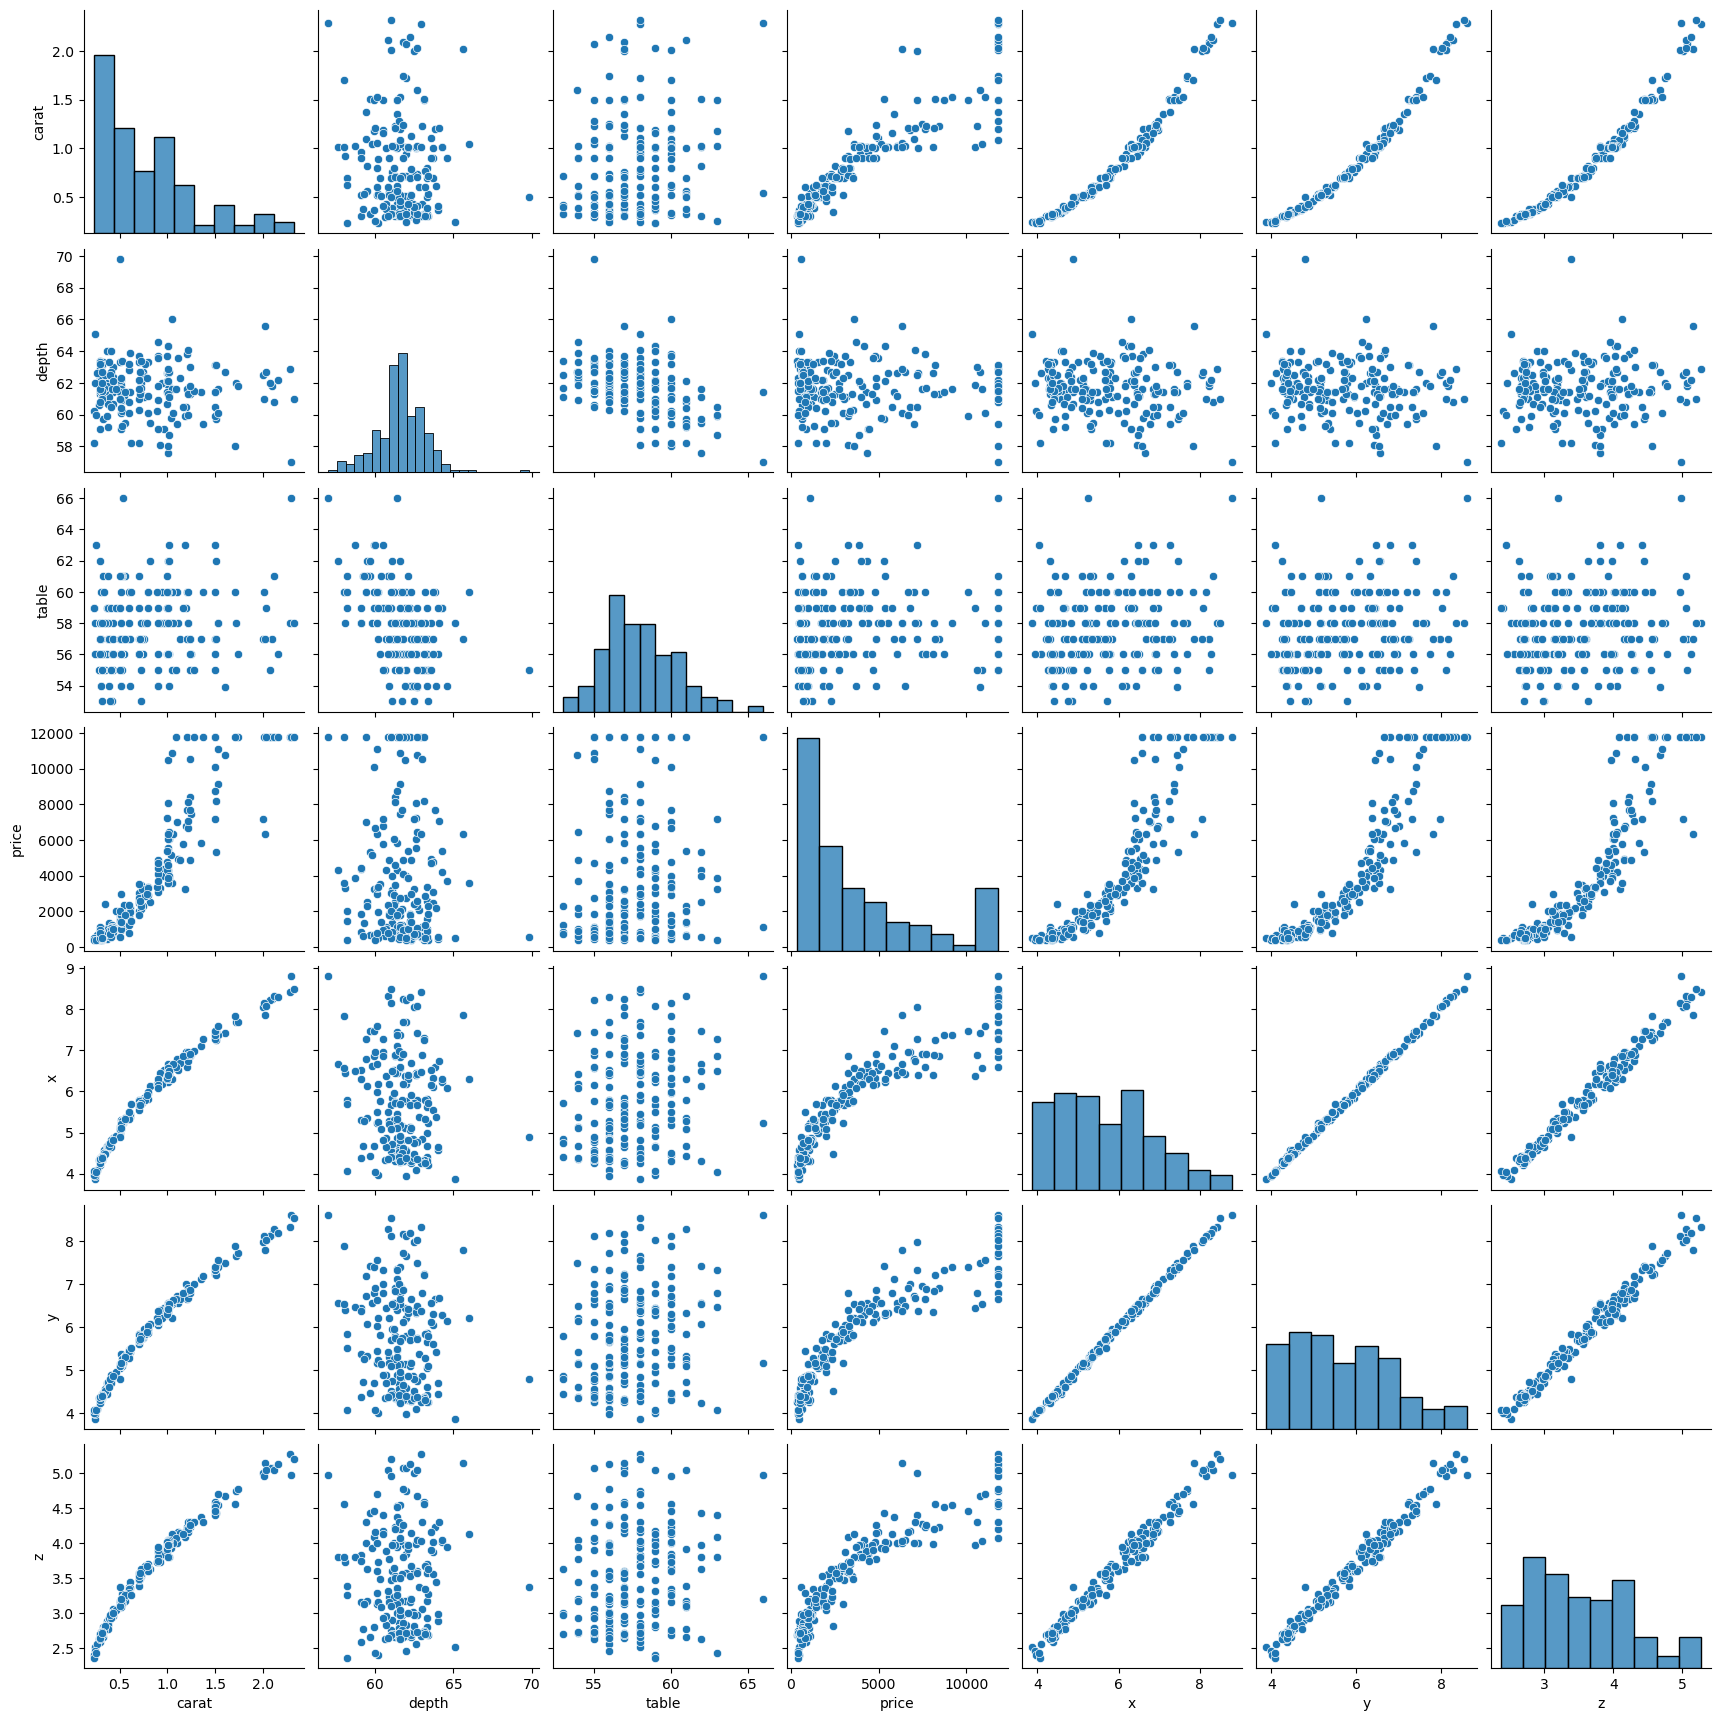

In [30]:
# Pairplot for a quick multivariate overview (may be slow on large datasets).
sns.pairplot(df.select_dtypes(include=[np.number]).sample(200))  # Sample 200 rows for clarity
plt.show()

In [31]:
# =============================================================================
# 4. Feature Engineering and Transformation
# =============================================================================

In [32]:
# ----- 4.1 Encoding Categorical Variables -----
# Before encoding, let’s fix structural errors: standardize the case for 'cut' column.
df['cut'] = df['cut'].str.title()  # Convert to title case (e.g., 'Premium')
print("\nUnique values in 'cut' after standardization:", df['cut'].unique())


Unique values in 'cut' after standardization: ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']


In [34]:
# One-hot encode categorical features ('cut', 'color', 'clarity') using pandas get_dummies.
# We use drop_first=True to avoid dummy variable trap.
df_encoded = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)
print("Dataset shape after encoding categorical variables:", df_encoded.shape)

Dataset shape after encoding categorical variables: (53796, 24)


In [35]:
# ----- 4.2 Mathematical Transformations -----
# Check skewness of 'price'. If highly skewed, a log transformation can help.
print("\nSkewness of 'price' before transformation:", df_encoded['price'].skew())
# Apply log transformation if skewness > 1 or < -1.
df_encoded['price_log'] = np.log(df_encoded['price'] + 1)  # Add 1 to avoid log(0)
print("Skewness of 'price_log' after log transformation:", df_encoded['price_log'].skew())


Skewness of 'price' before transformation: 1.1508871019703
Skewness of 'price_log' after log transformation: 0.028012778760425183


In [38]:
# ----- 4.3 Feature Scaling -----
# Scale numerical features using StandardScaler or MinMaxScaler.
# Here, we use StandardScaler for features like 'carat' and 'depth'.
scaler = StandardScaler()
# List of numerical columns to scale (excluding the target 'price' and its log-transformed version).
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
print("\nNumerical features scaled using StandardScaler.", df_encoded[num_cols])


Numerical features scaled using StandardScaler.           carat     depth     table         x         y         z
0     -1.199406 -0.173468 -1.100461 -1.589406 -1.537566 -1.572590
1     -1.241653 -1.362375  1.585673 -1.642943 -1.660241 -1.742792
2     -1.199406 -3.390510  3.376429 -1.500178 -1.458703 -1.742792
3     -1.072665  0.455954  0.242606 -1.366335 -1.318503 -1.288920
4     -1.030418  1.085375  0.242606 -1.241415 -1.213353 -1.118718
...         ...       ...       ...       ...       ...       ...
53935 -0.164354 -0.663018 -0.205083  0.016709  0.022159 -0.054957
53936 -0.164354  0.945503 -1.100461 -0.036829  0.013397  0.101061
53937 -0.206601  0.735696  1.137984 -0.063597 -0.047941  0.030144
53938  0.131375 -0.523146  0.242606  0.373623  0.337609  0.285447
53939 -0.100983  0.316082 -1.100461  0.088091  0.118547  0.143612

[53796 rows x 6 columns]


In [39]:
# ----- 4.4 Feature Selection (Basic Example) -----
# We can drop features with very low variance or high correlation.
# For demonstration, suppose we want to remove one of the highly correlated features:
# For example, if 'x', 'y', and 'z' are highly correlated, we may choose to drop 'y' and 'z'.
# (In a real project, you might use domain knowledge or methods like VIF.)
df_encoded_reduced = df_encoded.drop(['y', 'z'], axis=1)
print("Reduced dataset shape after dropping 'y' and 'z':", df_encoded_reduced.shape)

Reduced dataset shape after dropping 'y' and 'z': (53796, 23)


In [40]:
# ----- 4.5 Binning/Discretization -----
# Bin the 'carat' feature into 4 categories (e.g., small, medium, large, extra large).
# First, reverse the scaling (if you want to interpret in original terms) or use the original 'carat' column.
# Here, we use the original unscaled 'carat' from the original dataframe.
bins = [df['carat'].min(), 0.5, 1.0, 1.5, df['carat'].max()]
labels = ['Small', 'Medium', 'Large', 'Extra Large']
df['carat_binned'] = pd.cut(df['carat'], bins=bins, labels=labels, include_lowest=True)
print("\nValue counts for binned 'carat':\n", df['carat_binned'].value_counts())


Value counts for binned 'carat':
 carat_binned
Small          18863
Medium         17477
Large          12037
Extra Large     5419
Name: count, dtype: int64


In [41]:
# ----- 4.6 Creating Interaction Terms -----
# Create an interaction term between 'carat' and 'depth' (using scaled features from df_encoded).
df_encoded_reduced['carat_depth_interaction'] = df_encoded_reduced['carat'] * df_encoded_reduced['depth']
print("Interaction term 'carat_depth_interaction' created.")

Interaction term 'carat_depth_interaction' created.


In [42]:
# ----- 4.7 Polynomial Features -----
# Generate polynomial features for 'carat' and 'table' up to degree 2.
# This can capture non-linear relationships between features.
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df_encoded_reduced[['carat', 'table']])
# Get feature names for clarity.
poly_feature_names = poly.get_feature_names_out(['carat', 'table'])
# Create a DataFrame for polynomial features.
df_poly = pd.DataFrame(poly_features, columns=poly_feature_names)
# Concatenate these new polynomial features with the reduced dataframe.
df_final = pd.concat([df_encoded_reduced.reset_index(drop=True), df_poly.reset_index(drop=True)], axis=1)
print("Polynomial features added. Final dataset shape:", df_final.shape)

Polynomial features added. Final dataset shape: (53796, 29)


In [43]:
# =============================================================================
# 5. Splitting Data into Training and Testing Sets
# =============================================================================

# For modeling purposes, let’s assume 'price_log' is our target variable.
# Define features X and target y.
X = df_final.drop(['price', 'price_log'], axis=1)  # Remove original price columns from features.
y = df_final['price_log']

# Split the data into 80% training and 20% testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (43036, 27)
Testing set shape: (10760, 27)


In [44]:
"""
Summary:
---------
1. We loaded the 'diamonds' dataset and intentionally introduced common data quality issues such as missing values, duplicate rows, 
   and structural errors.
2. We performed data cleaning by imputing missing values, removing duplicates, standardizing categorical entries, and capping outliers.
3. Exploratory Data Analysis (EDA) was conducted with histograms, box plots, scatter plots, and correlation heatmaps to understand the data distribution and relationships.
4. Feature engineering techniques included:
   - Encoding categorical variables using one-hot encoding.
   - Applying a log transformation to reduce skewness in the target variable.
   - Scaling numerical features.
   - Selecting/dropping features to reduce multicollinearity.
   - Binning a continuous variable.
   - Creating interaction terms and polynomial features to capture non-linear relationships.
5. Finally, we split the dataset into training and testing sets in preparation for modeling.

"""

"\nSummary:\n---------\n1. We loaded the 'diamonds' dataset and intentionally introduced common data quality issues such as missing values, duplicate rows, \n   and structural errors.\n2. We performed data cleaning by imputing missing values, removing duplicates, standardizing categorical entries, and capping outliers.\n3. Exploratory Data Analysis (EDA) was conducted with histograms, box plots, scatter plots, and correlation heatmaps to understand the data distribution and relationships.\n4. Feature engineering techniques included:\n   - Encoding categorical variables using one-hot encoding.\n   - Applying a log transformation to reduce skewness in the target variable.\n   - Scaling numerical features.\n   - Selecting/dropping features to reduce multicollinearity.\n   - Binning a continuous variable.\n   - Creating interaction terms and polynomial features to capture non-linear relationships.\n5. Finally, we split the dataset into training and testing sets in preparation for modeling.